# **PyTorch 기반 MNIST 실습**

## **1. 패키지 포함**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.10.0+cu128


## **2. 데이터셋 로드 및 전처리**

- ToTensor: 이미지를 PyTorch Tensor로 변환하고 픽셀 값을 0-1 범위로 정규화 (PIL Image -> Tensor)
- Normalize: 평균 0, 표준편차 1로 추가 정규화 (필수는 아니지만 모델 학습에 도움)

- 데이터 전처리를 위한 변환 정의

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 데이터셋의 평균과 표준편차
])

- MNIST 데이터셋 로드

In [4]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


- DataLoader를 사용하여 데이터 배치 단위로 로드

In [5]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

- 데이터셋 형태 확인 (배치, 채널, 높이, 너비)

In [6]:
sample_images, sample_labels = next(iter(train_loader))
print(f"학습 이미지 배치 형태: {sample_images.shape}, 학습 레이블 배치 형태: {sample_labels.shape}") # (Batch, Channel, Height, Width)

학습 이미지 배치 형태: torch.Size([64, 1, 28, 28]), 학습 레이블 배치 형태: torch.Size([64])


## **3. CNN 모델 구축**

- PyTorch nn.Module 사용

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 컨볼루션 계층 1: 입력 채널 1 (흑백), 출력 채널 32, 필터 3x3
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        # 컨볼루션 계층 2: 입력 채널 32, 출력 채널 64, 필터 3x3
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        # 맥스 풀링 계층
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 완전 연결 계층 (컨볼루션/풀링 후 Flatten된 특징 맵 크기에 따라 입력 차원 결정 필요)
        # MNIST 28x28 이미지 기준으로 계산:
        # conv1: (28-3+1) = 26x26
        # pool1: 26/2 = 13x13
        # conv2: (13-3+1) = 11x11
        # pool2: 11/2 = 5x5 (내림) -> 64 채널 * 5 * 5 = 1600
        self.fc1 = nn.Linear(in_features=64 * 5 * 5, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10) # 출력 클래스 10개 (0-9)

    def forward(self, x):
        # conv1 -> ReLU -> pool1
        x = self.pool(F.relu(self.conv1(x)))
        # conv2 -> ReLU -> pool2
        x = self.pool(F.relu(self.conv2(x)))

        # 특징 맵 평탄화 (배치 차원을 제외하고 1차원으로)
        x = x.view(-1, 64 * 5 * 5)

        # fc1 -> ReLU
        x = F.relu(self.fc1(x))
        # fc2 (출력)
        x = self.fc2(x)
        return x

- 모델 인스턴스 생성

In [8]:
model_pt = SimpleCNN()

- GPU 사용 가능 시 GPU로 모델 이동

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pt.to(device)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

- 모델 구조 요약 (torchsummary 사용 시 더 자세히 볼 수 있지만, 여기서는 간단히

In [10]:
print("\n--- PyTorch CNN 모델 구조 ---")
print(model_pt)


--- PyTorch CNN 모델 구조 ---
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## **4. 모델 컴파일 및 학습**

- 손실 함수 (Loss Function): 다중 클래스 분류에는 CrossEntropyLoss 사용

In [11]:
criterion = nn.CrossEntropyLoss()

- 최적화 함수 (Optimizer): Adam 사용

In [12]:
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

- 학습 함수

In [13]:
def train_model(model, device, train_loader, optimizer, epoch):
    model.train() # 모델을 학습 모드로 설정
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # 데이터를 해당 디바이스로 이동

        optimizer.zero_grad() # 이전 그래디언트 초기화
        output = model(data)  # 순전파
        loss = criterion(output, target) # 손실 계산
        loss.backward()       # 역전파
        optimizer.step()      # 가중치 업데이트

        running_loss += loss.item()
        if batch_idx % 100 == 0: # 100 배치마다 로그 출력
            print(f'Epoch: {epoch}, Batch: {batch_idx}/{len(train_loader)}, Loss: {loss.item():.6f}')
    return running_loss / len(train_loader)

- 평가 함수

In [14]:
def test_model(model, device, test_loader):
    model.eval() # 모델을 평가 모드로 설정 (dropout, batchnorm 비활성화)
    test_loss = 0
    correct = 0
    with torch.no_grad(): # 그래디언트 계산 비활성화 (메모리 절약, 속도 향상)
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() # 배치당 손실 누적
            pred = output.argmax(dim=1, keepdim=True) # 가장 높은 확률을 가진 클래스 예측
            correct += pred.eq(target.view_as(pred)).sum().item() # 맞춘 개수 카운트

    test_loss /= len(test_loader.dataset) # 평균 손실
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    return test_loss, accuracy

- 학습 시작

In [15]:
epochs_pt = 5
train_losses_pt = []
test_losses_pt = []
test_accuracies_pt = []

In [16]:
print("\n--- PyTorch CNN 모델 학습 시작 ---")
for epoch in range(1, epochs_pt + 1):
    train_loss = train_model(model_pt, device, train_loader, optimizer, epoch)
    train_losses_pt.append(train_loss)
    test_loss, test_accuracy = test_model(model_pt, device, test_loader)
    test_losses_pt.append(test_loss)
    test_accuracies_pt.append(test_accuracy)
print("--- PyTorch CNN 모델 학습 완료 ---")


--- PyTorch CNN 모델 학습 시작 ---
Epoch: 1, Batch: 0/938, Loss: 2.313404
Epoch: 1, Batch: 100/938, Loss: 0.150367
Epoch: 1, Batch: 200/938, Loss: 0.143097
Epoch: 1, Batch: 300/938, Loss: 0.104303
Epoch: 1, Batch: 400/938, Loss: 0.079062
Epoch: 1, Batch: 500/938, Loss: 0.092397
Epoch: 1, Batch: 600/938, Loss: 0.055169
Epoch: 1, Batch: 700/938, Loss: 0.024126
Epoch: 1, Batch: 800/938, Loss: 0.113966
Epoch: 1, Batch: 900/938, Loss: 0.042336

Test set: Average loss: 0.0000, Accuracy: 9865/10000 (98.65%)

Epoch: 2, Batch: 0/938, Loss: 0.006354
Epoch: 2, Batch: 100/938, Loss: 0.025930
Epoch: 2, Batch: 200/938, Loss: 0.072818
Epoch: 2, Batch: 300/938, Loss: 0.071419
Epoch: 2, Batch: 400/938, Loss: 0.254459
Epoch: 2, Batch: 500/938, Loss: 0.013615
Epoch: 2, Batch: 600/938, Loss: 0.014590
Epoch: 2, Batch: 700/938, Loss: 0.022394
Epoch: 2, Batch: 800/938, Loss: 0.051431
Epoch: 2, Batch: 900/938, Loss: 0.056919

Test set: Average loss: 0.0000, Accuracy: 9894/10000 (98.94%)

Epoch: 3, Batch: 0/938, Lo

## **5. 모델 평가 및 결과 시각화**

- 학습 과정 시각화(정확도)

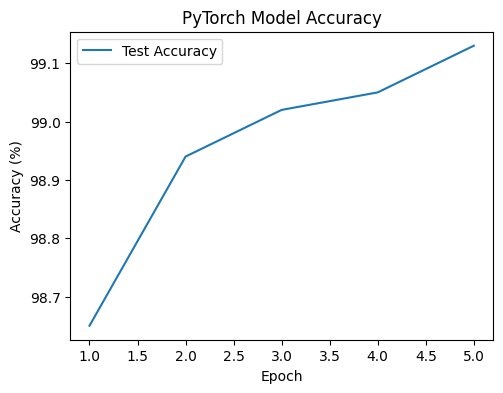

In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs_pt + 1), test_accuracies_pt, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('PyTorch Model Accuracy')
plt.legend()

- 학습 과정 시각화(손실)

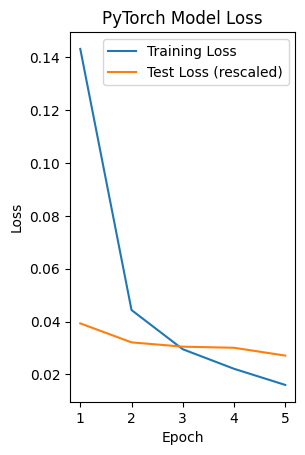

In [18]:
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs_pt + 1), train_losses_pt, label='Training Loss')
plt.plot(range(1, epochs_pt + 1), [l * test_loader.batch_size for l in test_losses_pt], label='Test Loss (rescaled)') # 테스트 로스 스케일 맞춰서
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch Model Loss')
plt.legend()
plt.show()

## **6. 예측**

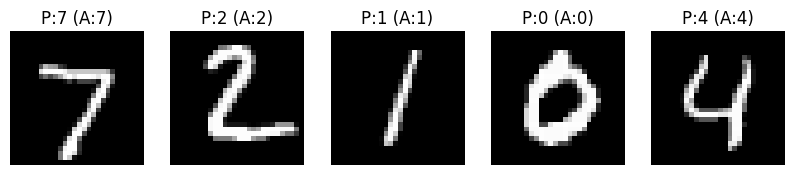

예측: [7, 2, 1, 0, 4]
실제: [7, 2, 1, 0, 4]


In [19]:
data, target = next(iter(test_loader))
data, target = data.to(device), target.to(device)
output = model_pt(data)
pred = output.argmax(dim=1, keepdim=True)

# --- 숫자 이미지 출력 코드 추가 ---
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(data[i].cpu().squeeze(), cmap='gray')
    plt.title(f"P:{pred[i].item()} (A:{target[i].item()})")
    plt.axis('off')
    # 예측이 틀렸을 경우 제목을 빨간색으로 표시하는 팁:
    if pred[i].item() != target[i].item():
        plt.gca().set_title(plt.gca().get_title(), color='red')
plt.show()
# ------------------------------

print(f"예측: {pred.flatten()[:5].tolist()}")
print(f"실제: {target[:5].tolist()}")